In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=True)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [2]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "25"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

In [3]:
data = pd.read_csv("../data/initial_population.txt")
data.head()

,age,r_initial,phi_initial,x_initial,y_initial,z_initial,v_r_initial,v_phi_initial,v_z_initial,vp_r,vp_phi,vp_z,v_orb
0,[yr],[kpc],[rad],[kpc],[kpc],[kpc],[kpc / yr],[kpc /yr],[kpc / yr],[kpc / yr],[kpc /yr],[kpc / yr],[kpc / yr]
1,41043580.27054155,9.69908325332439,8.665705545274145,-7.036439820724271,6.675382431310092,-0.2803978639907607,2.505909384277558e-07,-5.6255267581277775e-08,-2.3053309226625393e-07,2.505909384277558e-07,1.6620412116540165e-07,-2.3053309226625393e-07,-2.2245938874667942e-07
2,69981269.62275673,13.921400059238433,8.85690276817961,-11.736376290392407,7.487513016995619,0.3516868584471233,4.112259680724916e-07,-7.749870815996104e-07,4.0810282633023664e-07,4.112259680724916e-07,-5.697452528652625e-07,4.0810282633023664e-07,-2.0524182873434786e-07
3,67537915.57516164,3.4137693337739408,1.3678514858246154,0.6880609309860228,3.3437094998617964,0.15256026681105125,5.905676642150941e-08,2.8674515812605646e-07,3.478976437755187e-07,5.905676642150941e-08,4.980355915550689e-07,3.478976437755187e-07,-2.1129043342901244e-07
4,4852378.487182634,3.5784340822104683,5.302209953967624,1.9903688854586192,-2.9738228226516275,-0.10129697726582547,-5.404841830652307e-07,-8.358243963804873e-07,9.436104386039268e-07,-5.404841830652307e-07,-6.229376024930004e-07,9.436104386039268e-07,-2.1288679388748688e-07


In [4]:
data = data[1:]
data.head()

,age,r_initial,phi_initial,x_initial,y_initial,z_initial,v_r_initial,v_phi_initial,v_z_initial,vp_r,vp_phi,vp_z,v_orb
1,41043580.27054155,9.69908325332439,8.665705545274145,-7.036439820724271,6.675382431310092,-0.2803978639907607,2.505909384277558e-07,-5.6255267581277775e-08,-2.3053309226625393e-07,2.505909384277558e-07,1.6620412116540165e-07,-2.3053309226625393e-07,-2.2245938874667942e-07
2,69981269.62275673,13.921400059238433,8.85690276817961,-11.736376290392407,7.487513016995619,0.3516868584471233,4.112259680724916e-07,-7.749870815996104e-07,4.0810282633023664e-07,4.112259680724916e-07,-5.697452528652625e-07,4.0810282633023664e-07,-2.0524182873434786e-07
3,67537915.57516164,3.4137693337739408,1.3678514858246154,0.6880609309860228,3.3437094998617964,0.15256026681105125,5.905676642150941e-08,2.8674515812605646e-07,3.478976437755187e-07,5.905676642150941e-08,4.980355915550689e-07,3.478976437755187e-07,-2.1129043342901244e-07
4,4852378.487182634,3.5784340822104683,5.302209953967624,1.9903688854586192,-2.9738228226516275,-0.10129697726582547,-5.404841830652307e-07,-8.358243963804873e-07,9.436104386039268e-07,-5.404841830652307e-07,-6.229376024930004e-07,9.436104386039268e-07,-2.1288679388748688e-07
5,33531687.954023533,5.429288887446345,8.868507514570528,-4.610716638563365,2.8667873835049784,-0.13342227454226077,-1.8602065742159913e-07,-1.646065620368819e-07,1.477207726667666e-07,-1.8602065742159913e-07,6.032724697761523e-08,1.477207726667666e-07,-2.2493380901449712e-07


In [5]:
r_initial = pd.to_numeric(data["r_initial"]).values
x_initial = pd.to_numeric(data["x_initial"]).values
y_initial = pd.to_numeric(data["y_initial"]).values
z_initial = pd.to_numeric(data["z_initial"]).values
vp_r = pd.to_numeric(data["vp_r"]).values
vp_phi = pd.to_numeric(data["vp_phi"]).values
vp_z = pd.to_numeric(data["vp_z"]).values
v_orb = pd.to_numeric(data["v_orb"]).values

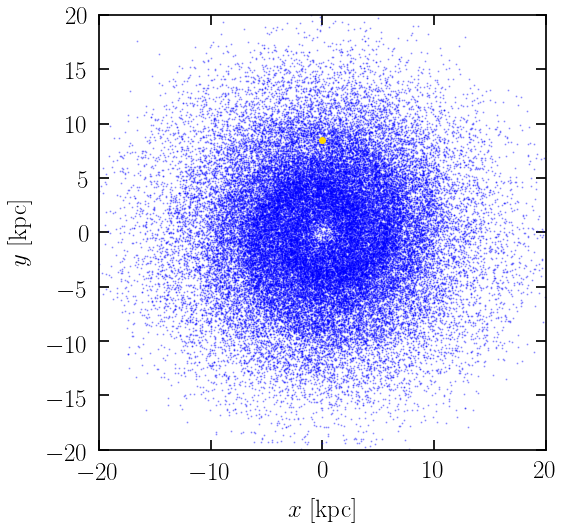

In [6]:
fig, ax = plt.subplots()

ax.plot(
    x_initial,
    y_initial,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

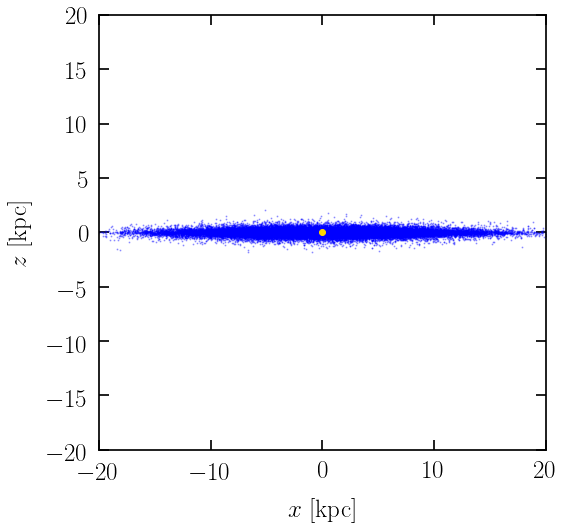

In [7]:
fig, ax = plt.subplots()

ax.plot(
    x_initial,
    z_initial,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

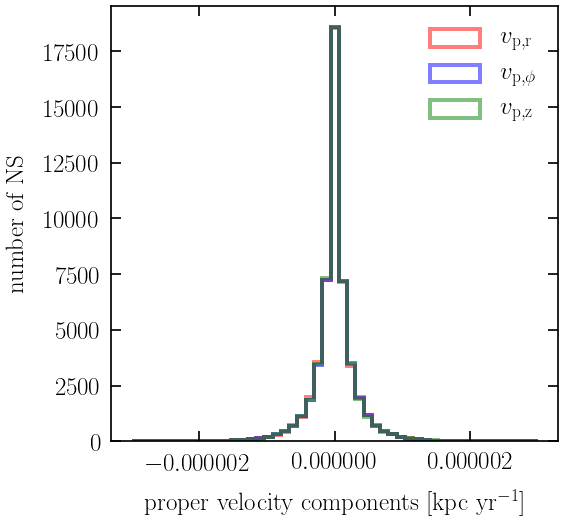

In [8]:
fig, ax = plt.subplots()
#x_bins = np.linspace(-2000.,2000.,50)  # bins for velocity in km / s
x_bins = np.linspace(-3.e-6,3.e-6,50)

ax.hist(vp_r, bins=x_bins,histtype='step',edgecolor='red',lw=4,alpha=0.5,label=r'$v_{\rm{p,}r}$')
ax.hist(vp_phi, bins=x_bins,histtype='step',edgecolor='blue',lw=4,alpha=0.5,label=r'$v_{\rm{p,}\phi}$')
ax.hist(vp_z, bins=x_bins,histtype='step',edgecolor='green',lw=4,alpha=0.5,label=r'$v_{\rm{p,}z}$')
ax.set_xlabel(r'proper velocity components [kpc yr$^{-1}$]')
ax.set_ylabel(r'number of NS')
plt.legend(frameon=False,loc=0)

plt.show()

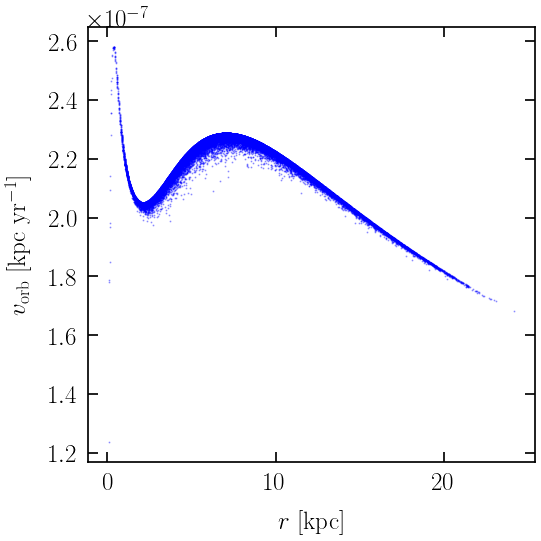

In [9]:
fig, ax = plt.subplots()

ax.plot(
    r_initial,
    abs(v_orb),
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.set_xlabel(r"$r$ [kpc]")
ax.set_ylabel(r"$v_{\rm orb}$ [kpc yr$^{-1}$]")

plt.show()

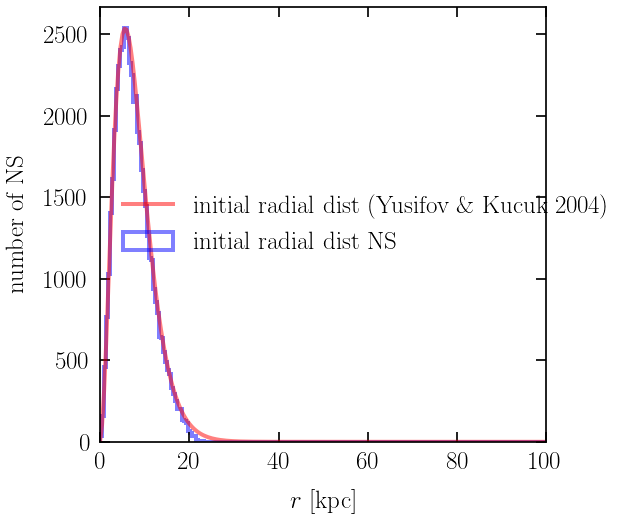

In [14]:
def pdf_r(r):
    'pdf from the Milky Way stellar surface density (Yusifov & Küçük 2004)'
    A = 37.6  # [stars kpc^-2]
    R1 = 0.55  # +-0.1 [kpc]
    Rsun = 8.5
    a = 1.64  # +-0.11
    b = 4.01  # +-0.24
    rho = A * ((r + R1) / (Rsun + R1)) ** a * np.exp(-b * ((r - Rsun) / (Rsun + R1)))
    pdf_r = 2*np.pi*r * rho
    return pdf_r


#r_bins = np.logspace(np.log10(0.0001), np.log10(100.), 100)
r_bins = np.linspace(0., 100., 220)

fig, ax = plt.subplots()

ax.hist(r_initial, bins=r_bins, histtype='step', edgecolor='blue', lw=4, alpha=0.5, label='initial radial dist NS')
ax.plot(r_bins, pdf_r(r_bins), linestyle='-', lw=4, color='red', alpha=0.5, label='initial radial dist (Yusifov \& Kucuk 2004)')
plt.xlabel(r'$r$ [kpc]')
plt.ylabel(r'number of NS')
plt.xlim(0.,100.)
plt.legend(frameon=False,loc=0)

plt.show()